<h1 style="text-align: center;">[Dekoruma Analysis]</h1>
<h3 style="text-align: center;">[Elmar Leonard and Firsa Adam]</h3>

---

## **Section 1. Business Context**

**1.1 Context**

Dekoruma is a technology company founded in 2015 by Dimas Harry Priawan and Aruna Harsa, with a mission to drive efficiency in Indonesia’s home and living industry. The company addresses key consumer challenges: time-consuming furniture shopping, lack of price transparency, and difficulty finding designs that fit urban living spaces.
Recognizing that Indonesian consumers prefer to experience furniture before making high-value purchases, Dekoruma adopted an Online-to-Offline (O2O) model by establishing multiple Dekoruma Experience Centers (DEC) across major cities. This strategy has successfully enhanced customer trust and significantly boosted conversion rates.


**1.2 Problem Statements**

Dekoruma currently faces a critical operational bottleneck: soaring return logistics costs coupled with a sharp decline in customer satisfaction. This double-edged challenge stems directly from a widening gap between furniture delivery schedules and assembly team arrivals. Compounding this issue, assembly teams frequently encounter missing components or damaged panels upon arrival. This forces immediate order cancellations and triggers expensive reverse logistics. Furthermore, Dekoruma Experience Centers (DECs) are experiencing a profound shift in utility; customers increasingly treat these showrooms as physical touchpoints to test products before purchasing them online. While DECs remain crucial for driving final purchasing decisions, this consumer shift leaves the physical centers with severely deflated performance metrics.

**1.3 Key Objective**

1. **Logistics Synchronization:** Establish system architecture rules that mandate vehicle delivery (Rider) and assembly team (Installer) schedules occur on the exact same day, enforcing a strict maximum variance of 24 hours.
1. **Supplier Quality Control:** Implement a vendor penalty and blacklisting framework targeting furniture suppliers with the highest rates of missing components and defective panels.
1. **Omnichannel Attribution:** Restructure the sales data and attribution models to ensure DEC Sales Consultants receive accurate commission incentives when a customer transacts via the mobile app post-showroom visit.
1. **Data Cleansing:** Eradicate system vulnerabilities by introducing strict logical validations, blocking users from inputting assembly dates that precede a 'Delivered' shipping manifest status.


## **Section 2. Data Understanding**

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import scipy

from IPython.display import Image, display

import sys
import os

**Importing Function**

In [3]:
src_path = os.path.abspath(os.path.join(os.getcwd(), "..", "src"))
if src_path not in sys.path:
    sys.path.append(src_path)

from utils import rename_cat

**Calling data**
> inserting all the data from csv into the notebook in form of dataframe

In [4]:
df_raw_orders = pd.read_csv(r"..\data\raw\dekoruma_orders.csv")
df_raw_products = pd.read_csv(r"..\data\raw\dekoruma_products.csv")
df_raw_stores = pd.read_csv(r"..\data\raw\dekoruma_stores.csv")

**2.1 General Information**

**Checking orders columns information**
> checking the data in the dataframe. Checking like this would allow us to see the connection between each tables of data and what is the column with the type of data inside of the column. making us know what should we casting later on if it doesnt fit with the correct information we need just yet.

In [5]:
df_raw_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   order_id             300000 non-null  object
 1   store_id             300000 non-null  object
 2   sku_id               300000 non-null  object
 3   order_date           300000 non-null  object
 4   delivery_date        300000 non-null  object
 5   installer_id         190275 non-null  object
 6   installation_date    190275 non-null  object
 7   installation_status  300000 non-null  object
 8   assembly_fee         300000 non-null  int64 
dtypes: int64(1), object(8)
memory usage: 20.6+ MB


**Checking products columns information**
> checking the data in the dataframe. Checking like this would allow us to see the connection between each tables of data and what is the column with the type of data inside of the column. making us know what should we casting later on if it doesnt fit with the correct information we need just yet.

In [6]:
df_raw_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   sku_id                1500 non-null   object
 1   product_name          1500 non-null   object
 2   category              1500 non-null   object
 3   is_assembly_required  1500 non-null   bool  
dtypes: bool(1), object(3)
memory usage: 36.8+ KB


**Checking stores columns information**
> checking the data in the dataframe. Checking like this would allow us to see the connection between each tables of data and what is the column with the type of data inside of the column. making us know what should we casting later on if it doesnt fit with the correct information we need just yet.

In [7]:
df_raw_stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   store_id      40 non-null     object
 1   store_name    40 non-null     object
 2   channel_type  40 non-null     object
dtypes: object(3)
memory usage: 1.1+ KB


**2.2 Feature Information**

**In-depth Information Table Orders**
| Column Names         | Description                             |
|----------------------|-----------------------------------------  |
| `order_id`           | Identifikasi unik untuk setiap transaksi pesanan                       | 
| `store_id`           | Identifikasi unik toko atau channel tempat pesanan dibuat    | 
| `sku_id`             | Identifikasi unik produk yang dipesan                     | 
| `order_date`         | Tanggal dan waktu pesanan dibuat oleh pelanggan             |
| `delivery_date`      | Tanggal dan waktu produk dikirimkan ke lokasi pelanggan    |
| `installer_id`       | Identifikasi unik teknisi pemasang furnitur yang ditugaskan|
| `installation_date`  | Tanggal dan waktu pemasangan furnitur dilakukan; bernilai NaN jika tidak ada pemasangan| 
|`installation_status` | Status hasil pemasangan furnitur (Success / Failed - Missing Parts / Failed - Damaged Panel / No Assembly Service / No Assembly Required) |
| `assembly_fee`       | Biaya jasa pemasangan furnitur dalam satuan Rupiah; bernilai 0 jika tidak ada pemasangan|

**In-depth Information Table Products**
| Column Names          | Description                             |
|-----------------------|-----------------------------------------|
| `sku_id`              | Identifikasi unik produk                      | 
| `product_name`        | Nama lengkap produk furnitur             |
| `category`            | Kategori jenis produk furnitur (contoh: Wardrobe, Sofa, Office Chair, Dining Table, dll.)    |
| `is_assembly_required`| Indikator boolean apakah produk memerlukan pemasangan (True) atau tidak (False)                        |

**In-depth Information Table Stores**
| Column Names       | Description                             |
|--------------------|-----------------------------------------|
| `store_id`         | Identifikasi unik toko atau channel penjualan    | 
| `store_name`       | Nama toko atau channel penjualan (contoh: DEC Alam Sutera, Mobile App, Web)    | 
| `channel_type`     | Jenis channel penjualan: Physical Store (toko fisik DEC), Mobile App, atau Web             |

**2.3 Statistics Summary**

**Checking orders columns description**
> checking the statistics information in the dataframe. Checking like this would allow us to see the statistics information on the table which have numerical values.

In [8]:
df_raw_orders.describe()

,assembly_fee
count,3.000000e+05
mean,4.044456e+05
std,5.557956e+06
min,-1.500000e+05
25%,0.000000e+00
50%,9.000000e+04
75%,1.700000e+05
max,9.990000e+07


Dari hasil `describe()` pada tabel orders, diperoleh beberapa insight penting:

1. **Volume Data:** Dataset mencakup **300.000 baris transaksi** (`count = 300,000`), menunjukkan skala operasional Dekoruma yang cukup besar dan dataset ini representatif untuk analisis bisnis.

2. **Dominasi Pesanan Tanpa Pemasangan:** Nilai `25th percentile (Q1) = 0` dan `median = 90.000` mengindikasikan bahwa lebih dari 25% pesanan memiliki `assembly_fee = 0`, artinya sebagian signifikan produk tidak memerlukan jasa pemasangan. Ini selaras dengan adanya kategori produk `is_assembly_required = False`.

3. **Rentang Biaya Pemasangan Normal:** Nilai `median = Rp 90.000` dan `Q3 = Rp 170.000` menggambarkan bahwa biaya pemasangan pada umumnya berkisar antara **Rp 50.000 hingga Rp 250.000**  angka yang wajar untuk jasa instalasi furnitur residensial di Indonesia.

4. **Anomali Nilai Negatif:** Nilai `minimum = -150.000` merupakan anomali yang tidak logis karena biaya pemasangan tidak seharusnya bernilai negatif. Hal ini mengindikasikan adanya **kesalahan input sistem** yang perlu ditangani pada tahap data cleaning.

5. **Anomali Nilai Ekstrem Atas:** Nilai `maximum = 99.900.000` sangat jauh melampaui nilai Q3 (Rp 170.000) dan mencurigakan. Nilai ini kemungkinan besar merupakan **nilai sentinel/placeholder** yang digunakan sistem untuk menandai kondisi tertentu, bukan nilai biaya pemasangan yang sesungguhnya perlu investigasi lebih lanjut di bagian identifikasi anomali.

6. **Standar Deviasi Sangat Tinggi:** Nilai `std = 5.557.956` yang jauh melampaui mean menunjukkan distribusi yang **sangat skewed ke kanan**, mayoritas dipicu oleh keberadaan nilai ekstrem 99.900.000 tersebut.

## **Section 3. Data Cleaning**

**3.1 Missing Values**

**Checking missing value data using isnull method**
> in this step we would be able to see how many null data inside each table so we can conclude why the data is missing and what should we do with it

In [9]:
print("=== ORDERS TABLE ===")
print(df_raw_orders.isnull().sum())

print("\n=== PRODUCTS TABLE ===")
print(df_raw_products.isnull().sum())

print("\n=== STORES TABLE ===")
print(df_raw_stores.isnull().sum())

=== ORDERS TABLE ===
order_id                    0
store_id                    0
sku_id                      0
order_date                  0
delivery_date               0
installer_id           109725
installation_date      109725
installation_status         0
assembly_fee                0
dtype: int64

=== PRODUCTS TABLE ===
sku_id                  0
product_name            0
category                0
is_assembly_required    0
dtype: int64

=== STORES TABLE ===
store_id        0
store_name      0
channel_type    0
dtype: int64


**In-Depth Dive into Missing Values**
> in this step we would dive deeper on the missing value on orders table to decide what type of missing value it is. is it MNAR, MAR, or MCAR.

**As we can see both missing value is on installer_id and installer date so we could check if the data missing is on the same row as it have the same amount of missing values**

In [10]:
df_raw_orders[(df_raw_orders["installer_id"].isnull())&(df_raw_orders["installation_date"].isnull())]

,order_id,store_id,sku_id,order_date,delivery_date,installer_id,installation_date,installation_status,assembly_fee
4,ORD-DKR00000005,DKR-019,SKU-FURN-01500,2023-12-15 12:00:00,2023-12-22 12:00:00,NaN,NaN,No Assembly Service,0
6,ORD-DKR00000007,DKR-025,SKU-FURN-01195,2023-02-14 09:00:00,2023-02-19 09:00:00,NaN,NaN,No Assembly Required,0
8,ORD-DKR00000009,DKR-022,SKU-FURN-00766,2023-07-29 13:00:00,2023-08-02 13:00:00,NaN,NaN,No Assembly Required,0
9,ORD-DKR00000010,DKR-026,SKU-FURN-01470,2023-12-29 10:00:00,2024-01-02 10:00:00,NaN,NaN,No Assembly Required,0
13,ORD-DKR00000014,DKR-020,SKU-FURN-01242,2023-07-02 14:00:00,2023-07-05 14:00:00,NaN,NaN,No Assembly Required,0
...,...,...,...,...,...,...,...,...,...
299991,ORD-DKR00299992,DKR-036,SKU-FURN-00004,2023-04-14 10:00:00,2023-04-18 10:00:00,NaN,NaN,No Assembly Service,0
299992,ORD-DKR00299993,DKR-019,SKU-FURN-01008,2023-10-07 16:00:00,2023-10-12 16:00:00,NaN,NaN,No Assembly Required,0
299996,ORD-DKR00299997,DKR-012,SKU-FURN-00579,2023-11-28 12:00:00,2023-12-04 12:00:00,NaN,NaN,No Assembly Required,0
299998,ORD-DKR00299999,DKR-031,SKU-FURN-01007,2023-09-06 11:00:00,2023-09-11 11:00:00,NaN,NaN,No Assembly Required,0


**from the result we can see that the row that have missing values is still 109725 even after we use a condition to call rows that have missing values on both installer_id and installation_date. Other than that as we now knew both of them correlated we can see as well all of the data that have missing row have assembly_fee of 0, with this we can make a first assumption that the data is missing not at random but because it has no assembly fee.**

**Testing first assumption**

In [11]:
df_raw_orders[(df_raw_orders["installer_id"].isnull())&(df_raw_orders["installation_date"].isnull())&(df_raw_orders["assembly_fee"]>0)]

,order_id,store_id,sku_id,order_date,delivery_date,installer_id,installation_date,installation_status,assembly_fee


**from this code we can conclude that the first assumption is correct with no rows with null values if the assembly fee is larger than zero. now we can do a more in depth research using installation status of each type**

In [12]:
df_raw_orders["installation_status"].unique()

array(['Success', 'No Assembly Service', 'No Assembly Required',
       'Failed - Missing Parts', 'Failed - Damaged Panel'], dtype=object)

**Checking if there is a null value in Success Status**

In [13]:
df_raw_orders[(df_raw_orders["installation_status"]=="Success")&(df_raw_orders["installer_id"].isnull())]

,order_id,store_id,sku_id,order_date,delivery_date,installer_id,installation_date,installation_status,assembly_fee


**Checking if there is a null value in Failed - Missing Parts Status**

In [14]:
df_raw_orders[(df_raw_orders["installation_status"]=="Failed - Missing Parts")&(df_raw_orders["installer_id"].isnull())]

,order_id,store_id,sku_id,order_date,delivery_date,installer_id,installation_date,installation_status,assembly_fee


**Checking if there is a null value in Failed - Damage Panel Status**

In [15]:
df_raw_orders[(df_raw_orders["installation_status"]=="Failed - Damage Panel")&(df_raw_orders["installer_id"].isnull())]

,order_id,store_id,sku_id,order_date,delivery_date,installer_id,installation_date,installation_status,assembly_fee


**Checking if there is a null value in No Assembly Service Status**

In [16]:
df_raw_orders[(df_raw_orders["installation_status"]=="No Assembly Service")&(df_raw_orders["installer_id"].isnull())]

,order_id,store_id,sku_id,order_date,delivery_date,installer_id,installation_date,installation_status,assembly_fee
4,ORD-DKR00000005,DKR-019,SKU-FURN-01500,2023-12-15 12:00:00,2023-12-22 12:00:00,NaN,NaN,No Assembly Service,0
27,ORD-DKR00000028,DKR-021,SKU-FURN-01464,2023-10-18 12:00:00,2023-10-20 12:00:00,NaN,NaN,No Assembly Service,0
38,ORD-DKR00000039,DKR-021,SKU-FURN-00911,2023-05-15 14:00:00,2023-05-19 14:00:00,NaN,NaN,No Assembly Service,0
73,ORD-DKR00000074,DKR-035,SKU-FURN-00348,2023-02-03 13:00:00,2023-02-05 13:00:00,NaN,NaN,No Assembly Service,0
79,ORD-DKR00000080,DKR-032,SKU-FURN-01049,2023-03-21 10:00:00,2023-03-27 10:00:00,NaN,NaN,No Assembly Service,0
...,...,...,...,...,...,...,...,...,...
299967,ORD-DKR00299968,DKR-040,SKU-FURN-00748,2023-05-06 16:00:00,2023-05-10 16:00:00,NaN,NaN,No Assembly Service,0
299979,ORD-DKR00299980,DKR-039,SKU-FURN-00540,2023-12-11 19:00:00,2023-12-13 19:00:00,NaN,NaN,No Assembly Service,0
299981,ORD-DKR00299982,DKR-026,SKU-FURN-00812,2023-01-14 12:00:00,2023-01-16 12:00:00,NaN,NaN,No Assembly Service,0
299991,ORD-DKR00299992,DKR-036,SKU-FURN-00004,2023-04-14 10:00:00,2023-04-18 10:00:00,NaN,NaN,No Assembly Service,0


**Checking if there is a null value in No Assembly Required Status**

In [17]:
df_raw_orders[(df_raw_orders["installation_status"]=="No Assembly Required")&(df_raw_orders["installer_id"].isnull())]

,order_id,store_id,sku_id,order_date,delivery_date,installer_id,installation_date,installation_status,assembly_fee
6,ORD-DKR00000007,DKR-025,SKU-FURN-01195,2023-02-14 09:00:00,2023-02-19 09:00:00,NaN,NaN,No Assembly Required,0
8,ORD-DKR00000009,DKR-022,SKU-FURN-00766,2023-07-29 13:00:00,2023-08-02 13:00:00,NaN,NaN,No Assembly Required,0
9,ORD-DKR00000010,DKR-026,SKU-FURN-01470,2023-12-29 10:00:00,2024-01-02 10:00:00,NaN,NaN,No Assembly Required,0
13,ORD-DKR00000014,DKR-020,SKU-FURN-01242,2023-07-02 14:00:00,2023-07-05 14:00:00,NaN,NaN,No Assembly Required,0
15,ORD-DKR00000016,DKR-016,SKU-FURN-01458,2023-05-20 13:00:00,2023-05-22 13:00:00,NaN,NaN,No Assembly Required,0
...,...,...,...,...,...,...,...,...,...
299988,ORD-DKR00299989,DKR-031,SKU-FURN-01493,2023-02-07 10:00:00,2023-02-13 10:00:00,NaN,NaN,No Assembly Required,0
299989,ORD-DKR00299990,DKR-004,SKU-FURN-00577,2023-01-21 15:00:00,2023-01-23 15:00:00,NaN,NaN,No Assembly Required,0
299992,ORD-DKR00299993,DKR-019,SKU-FURN-01008,2023-10-07 16:00:00,2023-10-12 16:00:00,NaN,NaN,No Assembly Required,0
299996,ORD-DKR00299997,DKR-012,SKU-FURN-00579,2023-11-28 12:00:00,2023-12-04 12:00:00,NaN,NaN,No Assembly Required,0


**After looking more in-depth on the information we have we now can confidently conclude that the missing values is not random but because of a reason that is if the installation is not needed for that product or there is no assembly service for that product then the installer_id and installation_date would be filled with NaN**

**As the missing values is not missing at random thats mean the missing values carries specific logical meaning so we should not leave the missing values as blank nor drop them.**


**installer_id will be filled with "NO INSTALLER" to inform that the order uses no installer**

**installation_date will be filled with placeholder datetime "1900-01-01 00:00:00" to inform that the order uses no installer so no time filled**

In [18]:
# fill installer_id 
df_raw_orders["installer_id"] = df_raw_orders["installer_id"].fillna("NO INSTALLER")
# fill installation_date
df_raw_orders["installation_date"] = df_raw_orders["installation_date"].fillna("1900-01-01 00:00:00")

In [19]:
df_raw_orders.head()

,order_id,store_id,sku_id,order_date,delivery_date,installer_id,installation_date,installation_status,assembly_fee
0,ORD-DKR00000001,DKR-029,SKU-FURN-00208,2023-08-10 17:00:00,2023-08-14 17:00:00,TUKANG-0882,2023-08-18 17:00:00,Success,120000
1,ORD-DKR00000002,DKR-012,SKU-FURN-01157,2023-01-30 10:00:00,2023-02-02 10:00:00,TUKANG-0560,2023-02-02 10:00:00,Success,110000
2,ORD-DKR00000003,DKR-032,SKU-FURN-00904,2023-07-13 20:00:00,2023-07-19 20:00:00,TUKANG-0631,2023-07-24 20:00:00,Success,230000
3,ORD-DKR00000004,DKR-005,SKU-FURN-00341,2023-09-27 19:00:00,2023-10-02 19:00:00,TUKANG-0484,2023-10-04 19:00:00,Success,100000
4,ORD-DKR00000005,DKR-019,SKU-FURN-01500,2023-12-15 12:00:00,2023-12-22 12:00:00,NO INSTALLER,1900-01-01 00:00:00,No Assembly Service,0


**3.2 Duplicated Values**

**Checking duplicated values in every table**
> in this step we would be able to see how many duplicated data inside each table so we can conclude why the data is duplicated and what should we do with it

In [20]:
print(f"Total Duplicate Row in Orders Table: {df_raw_orders.duplicated().sum()}")
print(f"Total Duplicate Row in Products Table: {df_raw_products.duplicated().sum()}")
print(f"Total Duplicate Row in Stores Table: {df_raw_stores.duplicated().sum()}")

Total Duplicate Row in Orders Table: 0
Total Duplicate Row in Products Table: 0
Total Duplicate Row in Stores Table: 0


**No duplicated row found**

**3.3 Identify Spelling Errors**

**Checking spelling value data using unique method**
> in this step we would be able to see how many unique data inside each table so we can conclude if the value spelling is error or not

In [21]:
df_raw_stores["store_name"].unique()

array(['DEC Alam Sutera 1', 'DEC Bintaro 2', 'DEC Kemang 3',
       'DEC Kelapa Gading 4', 'DEC Medan 5', 'DEC Kemang 6',
       'DEC Surabaya 7', 'DEC Bandung 8', 'DEC Kelapa Gading 9',
       'DEC Kemang 10', 'DEC Kelapa Gading 11', 'DEC Bintaro 12',
       'DEC Surabaya 13', 'DEC Kelapa Gading 14', 'DEC Bekasi 15',
       'DEC Bekasi 16', 'DEC Medan 17', 'DEC Alam Sutera 18',
       'DEC Alam Sutera 19', 'DEC Surabaya 20', 'DEC Bekasi 21',
       'DEC Alam Sutera 22', 'DEC Kelapa Gading 23', 'DEC Alam Sutera 24',
       'DEC Bekasi 25', 'DEC Bandung 26', 'DEC Alam Sutera 27',
       'DEC Surabaya 28', 'DEC Kelapa Gading 29', 'DEC Kemang 30',
       'DEC Bintaro 31', 'DEC Medan 32', 'DEC Alam Sutera 33',
       'DEC Bintaro 34', 'DEC Surabaya 35', 'DEC Alam Sutera 36',
       'DEC Kelapa Gading 37', 'DEC Bintaro 38', 'Dekoruma Mobile App',
       'Dekoruma Website'], dtype=object)

In [22]:
df_raw_stores["channel_type"].unique()

array(['Physical Store', 'Mobile App', 'Web'], dtype=object)

In [23]:
df_raw_products["category"].unique()

array(['Office Chair', 'Wardrobe', 'Sofa', 'Kursi Kerja', 'Lemari',
       'sofabed', 'Dekorasi', 'Dining Table', 'lmri', 'Meja Makan', 'Bed'],
      dtype=object)

**As we can see from the unique tested on some columns in the the table there are some values that is misspelled or differently written eventhough it describe the same category.**

**In-depth Analysis on Each Similiar Category**

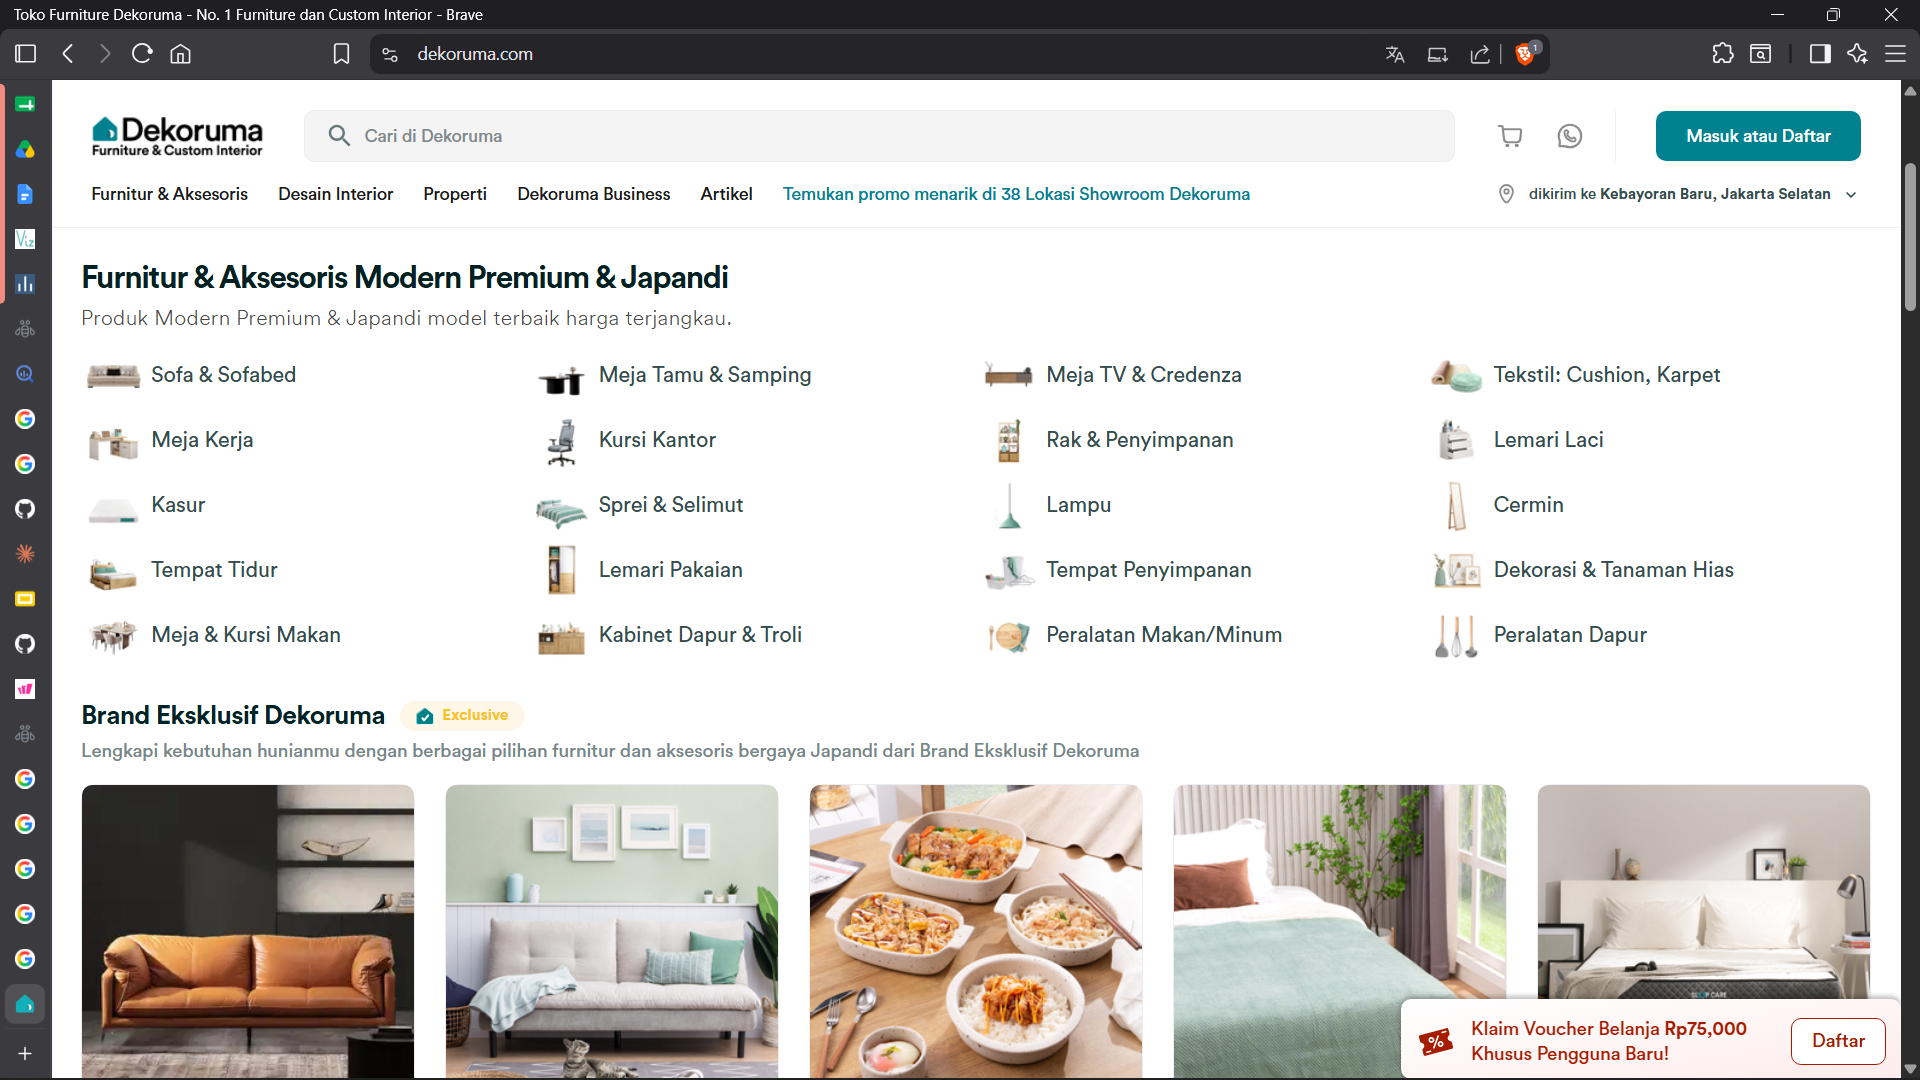

In [24]:
display(Image(filename=r"..\src\Furniture Types.png"))

1. **Sofa and sofabed is included in one category**
1. **Office chair is only one category**
1. **Wardrobe is only one category**
1. **Dining Table is only one category**

**Based on that information we would do some changing on the category so it will be in uniform**

In [25]:
df_raw_products["category"] = df_raw_products["category"].apply(lambda x: rename_cat(x))

In [26]:
df_raw_products["category"].unique()

array(['Office Chair', 'Wardrobe', 'Sofa & Sofabed', 'Decoration',
       'Dining Table', 'Bed'], dtype=object)

**3.4 Identify Anomaly Values**

**Checking anomaly valus in data using boxplot and iqr**
> in this step we would be able to see how many outlier in the data set

**Making boxplot to allow us do an observation based on chart**

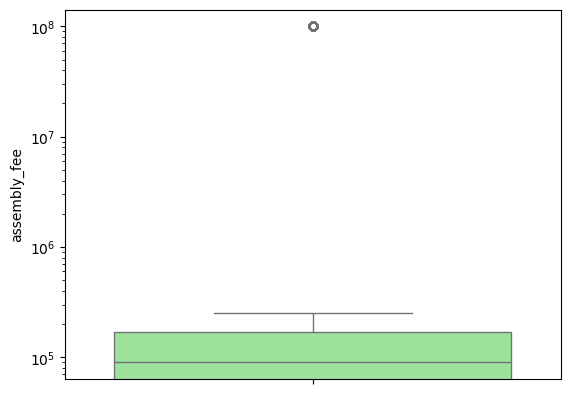

In [27]:
sns.boxplot(df_raw_orders["assembly_fee"], color="lightgreen").set_yscale('log')

**As we can see from the boxplot there are outliers in the assembly_fee column, next what we can do by knowing this information is to do an in-depth analysis on the column to know the outlier even better**

**calculate the outlier using quantile**
> We do this so we could now in-depth information about the outlier like how many there are and what is the assembly fee outlier value so we can analyze why it is an outlier

In [28]:
q1 = df_raw_orders["assembly_fee"].quantile(0.25)
q3 = df_raw_orders["assembly_fee"].quantile(0.75)
iqr = q3 - q1

upper = q3 + (iqr * 1.5)
lower = q1 - (iqr * 1.5)

print(f"total outlier: {df_raw_orders[(df_raw_orders["assembly_fee"]>upper)|(df_raw_orders["assembly_fee"]<lower)]["order_id"].count()}")

total outlier: 933


In [29]:
print(f"unique outlier value: {df_raw_orders[(df_raw_orders["assembly_fee"]>upper)]["assembly_fee"].unique()}")

unique outlier value: [99900000]


In [30]:
df_raw_orders[(df_raw_orders["assembly_fee"]>upper)]

,order_id,store_id,sku_id,order_date,delivery_date,installer_id,installation_date,installation_status,assembly_fee
1355,ORD-DKR00001356,DKR-004,SKU-FURN-01257,2023-01-15 09:00:00,2023-01-17 09:00:00,TUKANG-0628,2023-01-18 09:00:00,Success,99900000
2220,ORD-DKR00002221,DKR-022,SKU-FURN-00905,2023-12-30 16:00:00,2024-01-02 16:00:00,TUKANG-0812,2024-01-06 16:00:00,Success,99900000
2251,ORD-DKR00002252,DKR-006,SKU-FURN-00580,2023-10-15 12:00:00,2023-10-22 12:00:00,TUKANG-0694,2023-10-22 12:00:00,Success,99900000
2387,ORD-DKR00002388,DKR-010,SKU-FURN-00583,2023-02-26 20:00:00,2023-03-03 20:00:00,TUKANG-0802,2023-03-03 20:00:00,Success,99900000
2550,ORD-DKR00002551,DKR-037,SKU-FURN-00805,2023-03-13 12:00:00,2023-03-15 12:00:00,TUKANG-0004,2023-03-17 12:00:00,Success,99900000
...,...,...,...,...,...,...,...,...,...
299141,ORD-DKR00299142,DKR-037,SKU-FURN-01349,2023-05-08 09:00:00,2023-05-11 09:00:00,TUKANG-0224,2023-05-13 09:00:00,Success,99900000
299172,ORD-DKR00299173,DKR-026,SKU-FURN-00236,2023-10-13 19:00:00,2023-10-18 19:00:00,TUKANG-0790,2023-10-20 19:00:00,Success,99900000
299181,ORD-DKR00299182,DKR-003,SKU-FURN-01366,2023-01-11 20:00:00,2023-01-16 20:00:00,TUKANG-0022,2023-01-16 20:00:00,Success,99900000
299337,ORD-DKR00299338,DKR-004,SKU-FURN-00912,2023-10-14 12:00:00,2023-10-20 12:00:00,TUKANG-0006,2023-10-21 12:00:00,Success,99900000


In [31]:
outlier_negatif_count = (df_raw_orders['assembly_fee'] < 0).sum()
print("negatif outlier:", outlier_negatif_count)

negatif outlier: 960


In [33]:
outlier_pos = df_raw_orders[df_raw_orders['assembly_fee'] == 99900000]
print("=== installation_status on Outlier Positive ===")
print(outlier_pos['installation_status'].value_counts().reset_index())
print("Total positif outlier:", outlier_pos.value_counts().sum())

print()

outlier_neg = df_raw_orders[df_raw_orders['assembly_fee'] < 0]
print("=== installation_status on Outlier Negatif ===")
print(outlier_neg['installation_status'].value_counts().reset_index())
print("Total negatif outlier:", outlier_neg.value_counts().sum())

=== installation_status on Outlier Positive ===
      installation_status  count
0                 Success    748
1  Failed - Missing Parts    111
2  Failed - Damaged Panel     74
Total positif outlier: 933

=== installation_status on Outlier Negatif ===
      installation_status  count
0                 Success    786
1  Failed - Missing Parts    100
2  Failed - Damaged Panel     74
Total negatif outlier: 960


### Interpretasi

Nilai ekstrem pada kolom `assembly_fee` ditemukan dalam dua bentuk:

- **Outlier positif** (`99,900,000`): sebanyak **933 baris**. Nilai ini diduga merupakan *sentinel value* nilai dummy yang digunakan untuk menandai kondisi tertentu dalam sistem, bukan biaya rakitan yang sesungguhnya.
- **Outlier negatif** (`< 0`): sebanyak **960 baris**. Biaya rakitan tidak mungkin bernilai negatif dalam konteks bisnis nyata, sehingga nilai ini juga dianggap tidak valid.

Kedua jenis outlier ini tersebar di seluruh kategori `installation_status` (Success, Failed - Missing Parts, Failed - Damaged Panel), yang mengindikasikan bahwa **kemunculannya tidak berkaitan dengan status instalasi tertentu**. Artinya, outlier ini bukan hasil dari kondisi bisnis spesifik, melainkan kemungkinan besar berasal dari **kesalahan input atau placeholder sistem**.

## **Section 4. Analytics**

### **4.1 Question 1**

### **4.2 Question 2**

## **Section 5. Conclusion and Recommendation**

**5.1 Conclusion**

**5.2 Recommendation**